### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


### Loading Dataset

In [ ]:
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

x_train shape: (60000, 28, 28)
x_test shape: (10000, 28, 28)


### Pre-Processing

1) scale: from 0-255 to 0-1
2) reshape: (28,28,1) explicit channel dimension

In [3]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

x_train shape: (60000, 28, 28, 1)
x_test shape: (10000, 28, 28, 1)


### Introducing Noise to Images

- adding simple Gaussian noise to each image

In [4]:
noise_factor = 0.4

def add_noise(images, noise_factor=noise_factor):
    noisy = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    noisy = np.clip(noisy, 0.0, 1.0)
    return noisy.astype("float32")

x_train_noisy = add_noise(x_train)
x_test_noisy = add_noise(x_test)

print("Noisy train shape:", x_train_noisy.shape)

Noisy train shape: (60000, 28, 28, 1)


### Clean vs Noisy Visualisation

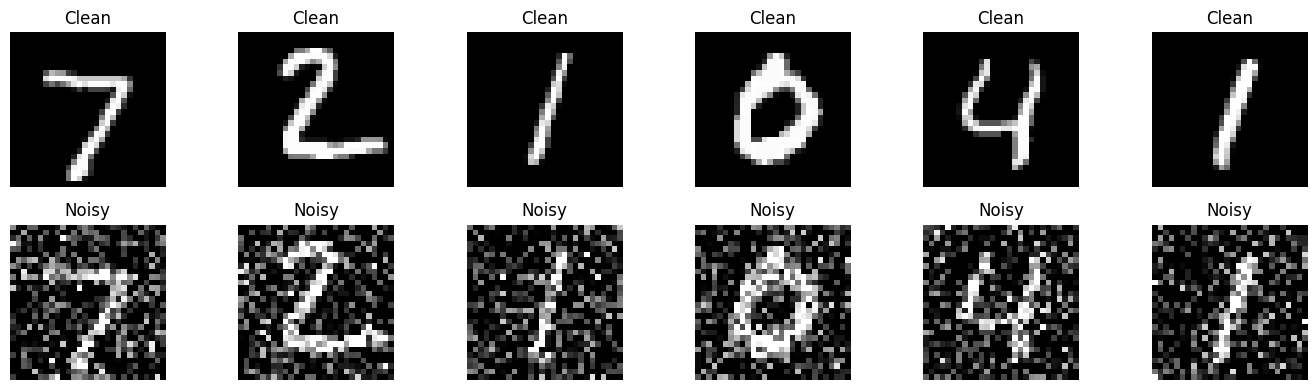

In [7]:
n = 6
plt.figure(figsize=(14, 4))
for i in range(n):
    # Clean
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title("Clean")
    plt.axis("off")

    # Noisy
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

plt.tight_layout()
plt.show()